## MSTL Decomposition as Input Feature — Direct Forecasting

### Pendekatan notebook ini

MSTL dipakai sebagai **input feature**, bukan target (sama seperti ide nb07), TAPI dihitung dengan metode
yang **fully causal** — bisa dihitung identik di train maupun test tanpa butuh informasi masa depan:

| Komponen | Metode | Kenapa aman (no leakage) |
|---|---|---|
| `trend` | Trailing rolling mean, window=168 jam | Cuma pakai data ≤ t (observed value asli, bukan prediksi) |
| `seasonal_24` | Profil periodik per jam (0-23), **di-fit dari train saja** | Deterministik, lookup berdasar kalender |
| `seasonal_168` | Profil periodik per (weekday × jam) (0-167), **di-fit dari train saja** | Deterministik, lookup berdasar kalender |
| `resid` | `actual - trend - seasonal_24 - seasonal_168` | Pakai actual value yang sudah observed |

Ini secara sengaja menyederhanakan MSTL asli (yang pakai LOESS) demi **konsistensi statistik antara train
dan test** — supaya model tidak belajar dari fitur yang dihasilkan LOESS di train tapi dievaluasi dengan
fitur hasil metode lain saat test.

### Forecasting: **direct, one-step-ahead** (bukan recursive)

Sama seperti notebook 05 — model memprediksi `carbon_intensity` / `renewable_percentage` **langsung**,
menggunakan nilai historis asli (bukan hasil prediksi model sendiri) sebagai lag input. Tidak ada
rekonstruksi berjenjang, tidak ada compounding error.

### Tetap mempertahankan struktur 12 model

Dua temporal representation (**Dummy**, **Cyclical**) × enam arsitektur/target (**Uni-LSTM CI, Uni-LSTM RE,
Multi-LSTM, BiLSTM CI, BiLSTM RE, BiLSTM Multi**) = **12 model**, konsisten dengan nb06 versi sebelumnya
dan nb04/05.

Konfigurasi training tetap konsisten dengan notebook 04/05/06:
- temporal split 80:20
- look-back = 24
- one-step ahead
- seed = 42
- epochs = 50
- batch size = 32
- validation split = 0.1
- early stopping patience = 10
- shuffle = False

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Project root
project_root = next(
    (
        parent
        for parent in [Path.cwd(), *Path.cwd().parents]
        if (parent / "src").exists()
    ),
    Path.cwd()
)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_loader import TimeSeriesDataLoader

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("Project root:", project_root)
print("TensorFlow:", tf.__version__)

Project root: /Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app
TensorFlow: 2.21.0


In [2]:
# Load normalized feature-engineered dataset
feature_path = (
    project_root
    / "data"
    / "processed"
    / "normalized"
    / "dataset_feature_engineered.csv"
)

df = pd.read_csv(feature_path)

df["datetime"] = pd.to_datetime(
    df["datetime"],
    utc=True
)

df = (
    df
    .set_index("datetime")
    .sort_index()
)

CI_COL = "carbon_intensity"
RE_COL = "renewable_percentage"

print("Shape:", df.shape)
print("Date range:", df.index.min(), "→", df.index.max())
print("Missing CI:", df[CI_COL].isna().sum())
print("Missing RE:", df[RE_COL].isna().sum())

Shape: (17496, 84)
Date range: 2024-01-03 00:00:00+00:00 → 2025-12-31 23:00:00+00:00
Missing CI: 0
Missing RE: 0


In [3]:
# Reuse existing PACF-based lag configuration from the feature-engineered dataset.
# These are the SAME raw target lag columns used in notebooks 04 and 05.
ci_lag_cols = sorted(
    [
        col for col in df.columns
        if col.startswith("CI_lag_")
    ],
    key=lambda x: int(x.split("_")[-1])
)

re_lag_cols = sorted(
    [
        col for col in df.columns
        if col.startswith("RE_lag_")
    ],
    key=lambda x: int(x.split("_")[-1])
)

print("CI lag columns:", ci_lag_cols)
print("RE lag columns:", re_lag_cols)

CI lag columns: ['CI_lag_1', 'CI_lag_3', 'CI_lag_4', 'CI_lag_5', 'CI_lag_6', 'CI_lag_7', 'CI_lag_8', 'CI_lag_9', 'CI_lag_10', 'CI_lag_11', 'CI_lag_12', 'CI_lag_13', 'CI_lag_14', 'CI_lag_15', 'CI_lag_16', 'CI_lag_17', 'CI_lag_18', 'CI_lag_19', 'CI_lag_20', 'CI_lag_21', 'CI_lag_22', 'CI_lag_23', 'CI_lag_24', 'CI_lag_25', 'CI_lag_26', 'CI_lag_27', 'CI_lag_29', 'CI_lag_30', 'CI_lag_31', 'CI_lag_32', 'CI_lag_35', 'CI_lag_36', 'CI_lag_40', 'CI_lag_41', 'CI_lag_44', 'CI_lag_45', 'CI_lag_46', 'CI_lag_47', 'CI_lag_48']
RE lag columns: ['RE_lag_1', 'RE_lag_2', 'RE_lag_3', 'RE_lag_4', 'RE_lag_5', 'RE_lag_6', 'RE_lag_7', 'RE_lag_10', 'RE_lag_11', 'RE_lag_12', 'RE_lag_13', 'RE_lag_14', 'RE_lag_15', 'RE_lag_17', 'RE_lag_18', 'RE_lag_19', 'RE_lag_20', 'RE_lag_21', 'RE_lag_22', 'RE_lag_23', 'RE_lag_24', 'RE_lag_25', 'RE_lag_26', 'RE_lag_27', 'RE_lag_28', 'RE_lag_31', 'RE_lag_32', 'RE_lag_33', 'RE_lag_34', 'RE_lag_35', 'RE_lag_36', 'RE_lag_39', 'RE_lag_43', 'RE_lag_44', 'RE_lag_45', 'RE_lag_47', 'RE_la

In [4]:
# Drop rows with missing target values.
df_core = df.dropna(subset=[CI_COL, RE_COL]).copy()

# The pre-existing lag columns have NaN only at the very start of the FULL
# series (they are computed globally, not per-split), so this trim only
# affects the leading edge — well before the train/test cut point.
df_core = df_core.dropna(subset=[*ci_lag_cols, *re_lag_cols]).copy()

TRAIN_RATIO = 0.8
train_size = int(len(df_core) * TRAIN_RATIO)

train_raw = df_core.iloc[:train_size].copy()
test_raw = df_core.iloc[train_size:].copy()

TRAIN_END_INDEX = train_raw.index[-1]

print("Train:", train_raw.shape, train_raw.index.min(), "→", train_raw.index.max())
print("Test :", test_raw.shape, test_raw.index.min(), "→", test_raw.index.max())

Train: (13996, 84) 2024-01-03 00:00:00+00:00 → 2025-08-08 03:00:00+00:00
Test : (3500, 84) 2025-08-08 04:00:00+00:00 → 2025-12-31 23:00:00+00:00


## 1. Causal, leak-free decomposition (replaces recursive MSTL)

`compute_causal_decomposition()` below computes `trend`, `seasonal_24`, `seasonal_168`, and `resid`
for the **entire** index (train + test) in a single deterministic pass.

Only the **training portion** is used to fit the two seasonal profiles (`seasonal_24`, `seasonal_168`).
`trend` is a trailing rolling mean, which by construction only uses data at or before the current
timestamp — so it is valid to compute for test rows too, since those are real observed values, not
model-generated predictions.

This function is applied identically to train and test — there is no special-casing, no recursion, and
no dependency on future observations at any point.

In [5]:
def compute_causal_decomposition(series, train_end_index, trend_window=168):
    """
    Fully causal, leak-free decomposition, consistent across train and test.

    - trend: trailing rolling mean (window = trend_window). Uses only
      values at or before each timestamp.
    - seasonal_24 / seasonal_168: deterministic periodic profiles
      (mean by hour-of-day / by weekday-hour), fit ONLY on the training
      portion (index <= train_end_index), then looked up for every
      timestamp (train and test) via calendar position.
    - resid: whatever remains after removing trend + both seasonal
      profiles from the actual series.

    This intentionally simplifies statsmodels' MSTL (LOESS-based) into a
    decomposition that behaves identically at train and test time, so the
    model is not trained on one feature distribution and evaluated on
    another.
    """
    trend = series.rolling(window=trend_window, min_periods=1).mean()
    deseasonalized = series - trend

    train_deseasonalized = deseasonalized.loc[:train_end_index]

    # --- seasonal_24: profile fit on train only ---
    hour_profile = (
        train_deseasonalized
        .groupby(train_deseasonalized.index.hour)
        .mean()
    )
    seasonal_24 = pd.Series(
        series.index.hour.map(hour_profile).astype(float),
        index=series.index
    )

    # --- seasonal_168: profile fit on train only, after removing seasonal_24 ---
    residual_after_24 = (
        train_deseasonalized.values
        - train_deseasonalized.index.hour.map(hour_profile).astype(float)
    )
    weekhour_key_train = (
        train_deseasonalized.index.weekday * 24
        + train_deseasonalized.index.hour
    )
    weekhour_profile = (
        pd.Series(residual_after_24, index=weekhour_key_train)
        .groupby(level=0)
        .mean()
    )
    weekhour_key_full = series.index.weekday * 24 + series.index.hour
    seasonal_168 = pd.Series(
        weekhour_key_full.map(weekhour_profile).astype(float),
        index=series.index
    )

    # --- resid: whatever remains ---
    resid = series - trend - seasonal_24 - seasonal_168

    return pd.DataFrame(
        {
            "trend": trend,
            "seasonal_24": seasonal_24,
            "seasonal_168": seasonal_168,
            "resid": resid
        },
        index=series.index
    )


ci_decomp = compute_causal_decomposition(
    df_core[CI_COL], train_end_index=TRAIN_END_INDEX, trend_window=168
).add_prefix("CI_")

re_decomp = compute_causal_decomposition(
    df_core[RE_COL], train_end_index=TRAIN_END_INDEX, trend_window=168
).add_prefix("RE_")

CI_MSTL_COLS = ["CI_trend", "CI_seasonal_24", "CI_seasonal_168", "CI_resid"]
RE_MSTL_COLS = ["RE_trend", "RE_seasonal_24", "RE_seasonal_168", "RE_resid"]

mstl_feature_df = pd.concat([ci_decomp, re_decomp], axis=1)

print("MSTL-feature dataframe shape:", mstl_feature_df.shape)
print("Any NaN:", mstl_feature_df.isna().sum().sum())

# Sanity check: reconstruction should equal the original series (by construction).
ci_recon_error = (
    ci_decomp[CI_MSTL_COLS].sum(axis=1) - df_core[CI_COL]
).abs().max()
re_recon_error = (
    re_decomp[RE_MSTL_COLS].sum(axis=1) - df_core[RE_COL]
).abs().max()

print("Max CI reconstruction error:", ci_recon_error)
print("Max RE reconstruction error:", re_recon_error)

MSTL-feature dataframe shape: (17496, 8)
Any NaN: 0
Max CI reconstruction error: 1.1368683772161603e-13
Max RE reconstruction error: 3.552713678800501e-15


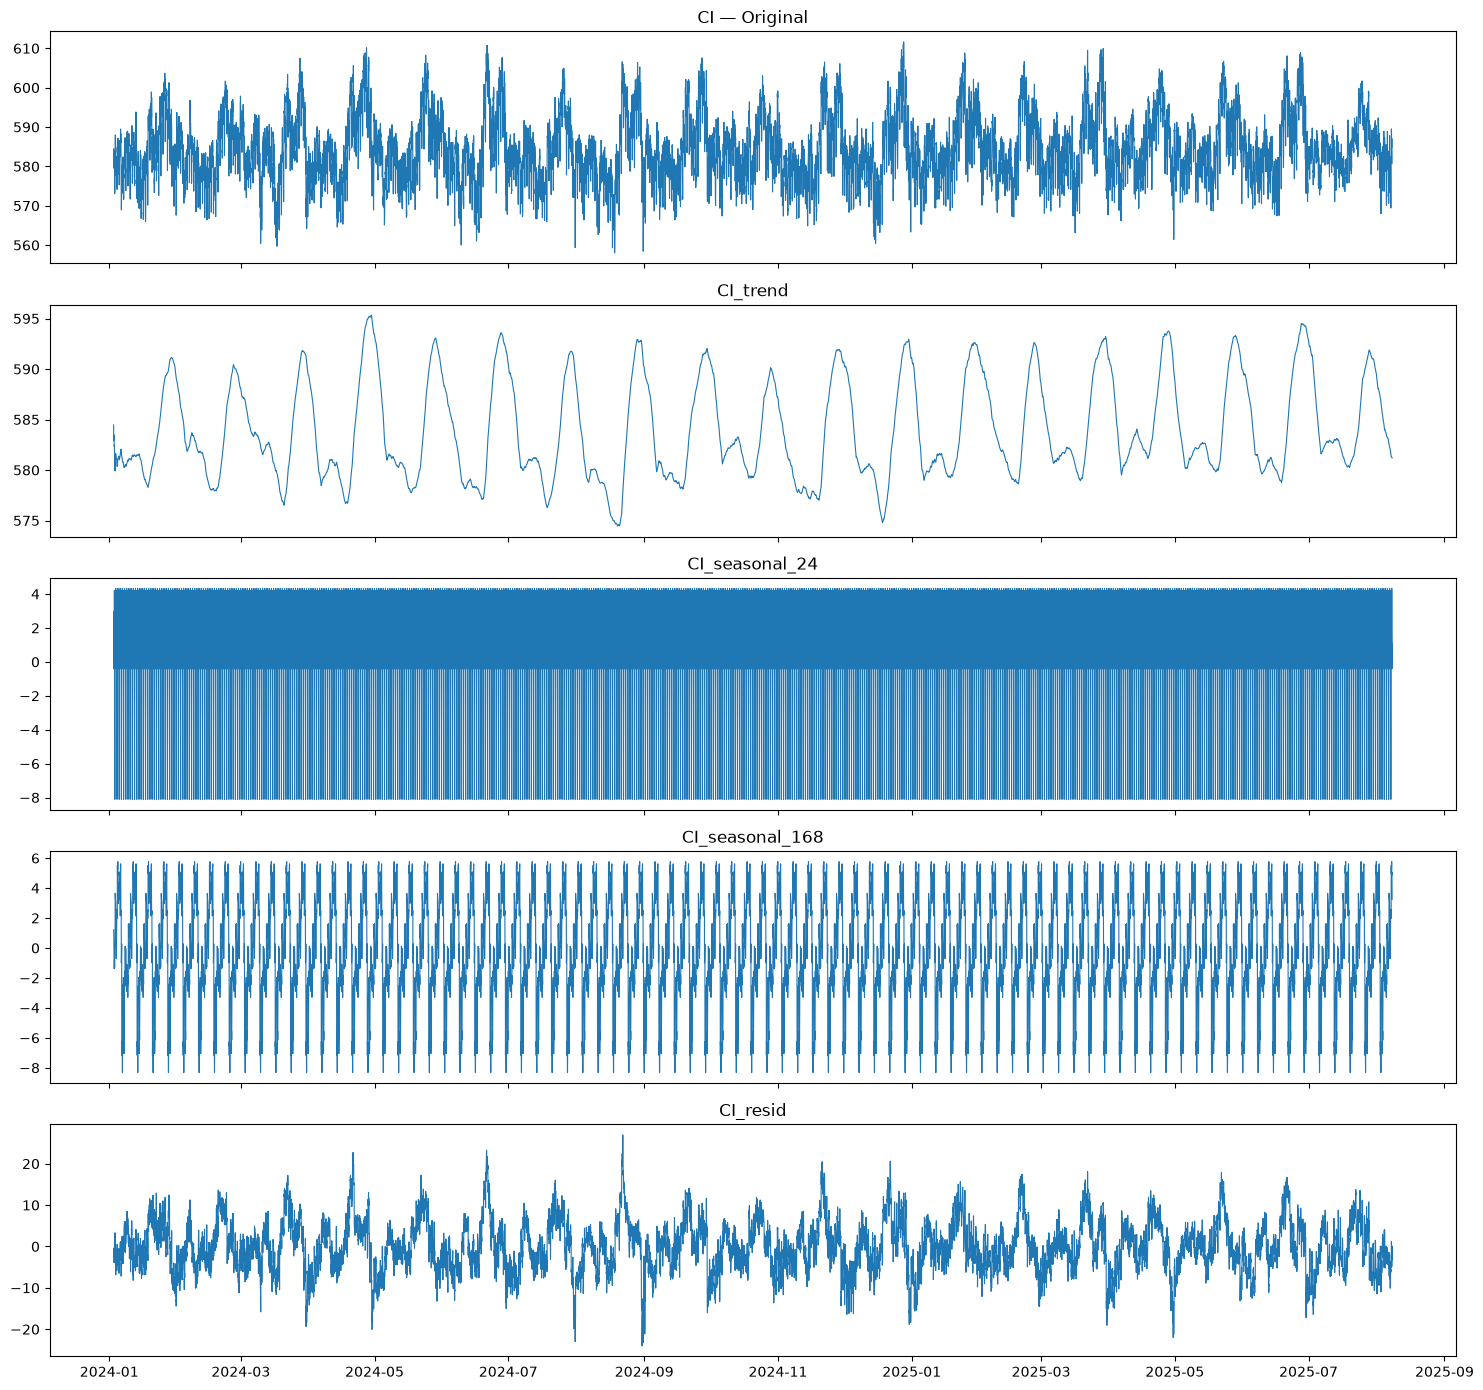

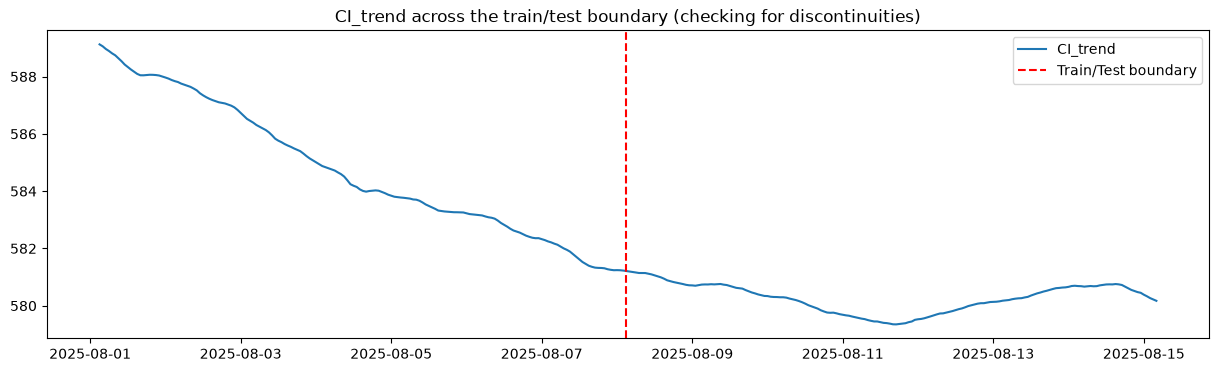

In [6]:
# Visualize the causal decomposition for CI (train period shown for readability).
fig, axes = plt.subplots(5, 1, figsize=(15, 14), sharex=True)

plot_slice = train_raw.index

axes[0].plot(plot_slice, df_core.loc[plot_slice, CI_COL], linewidth=0.8)
axes[0].set_title("CI — Original")

for ax, col in zip(axes[1:], CI_MSTL_COLS):
    ax.plot(plot_slice, ci_decomp.loc[plot_slice, col], linewidth=0.8)
    ax.set_title(col)

plt.tight_layout()
plt.show()

# Visualize across the train → test boundary, to confirm no discontinuity.
boundary_window = df_core.index[
    (df_core.index >= TRAIN_END_INDEX - pd.Timedelta(days=7))
    & (df_core.index <= test_raw.index[0] + pd.Timedelta(days=7))
]

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(boundary_window, ci_decomp.loc[boundary_window, "CI_trend"], label="CI_trend")
ax.axvline(TRAIN_END_INDEX, color="red", linestyle="--", label="Train/Test boundary")
ax.set_title("CI_trend across the train/test boundary (checking for discontinuities)")
ax.legend()
plt.show()

## 2. Temporal representations

Same as notebook 06 (previous version) and notebook 05:

- **Dummy:** daily hour, month, and weekday × hour interaction.
- **Cyclical:** hour, day-of-week, and month sin/cos.

These are deterministic calendar features computed for the **entire** index — they do not depend on
target values at all, so there is no leakage concern here.

In [7]:
TEMPORAL_CYCLICAL = [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos"
]

loader_time = TimeSeriesDataLoader()

all_index_df = pd.DataFrame(index=df_core.index)
all_index_df = loader_time.add_time_features(all_index_df)

cyclical_full = all_index_df[TEMPORAL_CYCLICAL].copy()

dummy_full = loader_time.add_seasonal_dummies(
    pd.DataFrame(index=df_core.index),
    daily=True,
    monthly=True,
    weekly_hour=True,
    drop_first=True
)

DUMMY_COLS = [
    col for col in dummy_full.columns
    if col.startswith("H_")
    or col.startswith("B_")
    or col.startswith("M")
]

print("Cyclical features:", TEMPORAL_CYCLICAL)
print("Number of dummy features:", len(DUMMY_COLS))

  Seasonal dummies added. Total columns: 201
Cyclical features: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
Number of dummy features: 201


In [8]:
# Assemble the full feature dataframe: raw targets + raw lags + causal
# MSTL-style components + both temporal representations.
df_features = df_core[[CI_COL, RE_COL, *ci_lag_cols, *re_lag_cols]].copy()
df_features[[*CI_MSTL_COLS, *RE_MSTL_COLS]] = mstl_feature_df[[*CI_MSTL_COLS, *RE_MSTL_COLS]]
df_features[TEMPORAL_CYCLICAL] = cyclical_full[TEMPORAL_CYCLICAL]
df_features[DUMMY_COLS] = dummy_full[DUMMY_COLS]

print("df_features shape:", df_features.shape)
print("NaN check:", df_features.isna().sum().sum())

df_features shape: (17496, 293)
NaN check: 0


## 3. Training configuration

Identical to notebooks 04/05/06 for comparability.

In [9]:
LOOK_BACK = 24
FORECAST_HORIZON = 1

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

EPOCHS = 50
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.1

def make_early_stopping():
    return EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

print("=== TRAINING CONFIGURATION ===")
print("Seed:", SEED)
print("Look-back:", LOOK_BACK)
print("Forecast horizon:", FORECAST_HORIZON)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Validation split:", VALIDATION_SPLIT)
print("Early stopping patience: 10")

=== TRAINING CONFIGURATION ===
Seed: 42
Look-back: 24
Forecast horizon: 1
Epochs: 50
Batch size: 32
Validation split: 0.1
Early stopping patience: 10


In [10]:
def build_lstm(input_shape, output_dim):
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dropout(0.2),
        Dense(output_dim)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


def build_bilstm(input_shape, output_dim):
    model = Sequential([
        Bidirectional(
            LSTM(64),
            input_shape=input_shape
        ),
        Dropout(0.2),
        Dense(output_dim)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

## 4. Experiment helpers — direct forecasting (no reconstruction, no recursion)

Each experiment predicts the **raw target value** directly. `split_and_scale` and `create_sliding_window`
are the same `TimeSeriesDataLoader` methods used in notebooks 04 and 05 — the scaler is fit on train only,
and windows for train/test are built independently after the split, exactly like the direct-forecasting
baseline.

In [11]:
def get_feature_target_cols(target_group, temporal_mode):
    temporal_cols = DUMMY_COLS if temporal_mode == "dummy" else TEMPORAL_CYCLICAL

    if target_group == "CI":
        feature_cols = [CI_COL, *ci_lag_cols, *CI_MSTL_COLS, *temporal_cols]
        target_cols = [CI_COL]
    elif target_group == "RE":
        feature_cols = [RE_COL, *re_lag_cols, *RE_MSTL_COLS, *temporal_cols]
        target_cols = [RE_COL]
    elif target_group == "MULTI":
        feature_cols = [
            CI_COL, RE_COL,
            *ci_lag_cols, *re_lag_cols,
            *CI_MSTL_COLS, *RE_MSTL_COLS,
            *temporal_cols
        ]
        target_cols = [CI_COL, RE_COL]
    else:
        raise ValueError("target_group must be CI, RE, or MULTI")

    return feature_cols, target_cols


def prepare_experiment(feature_cols, target_cols, train_ratio=TRAIN_RATIO):
    loader = TimeSeriesDataLoader()

    train_scaled, test_scaled = loader.split_and_scale(
        df=df_features,
        feature_cols=feature_cols,
        target_cols=target_cols,
        train_ratio=train_ratio
    )

    X_train, y_train = loader.create_sliding_window(
        train_scaled,
        target_cols=target_cols,
        look_back=LOOK_BACK,
        forecast_horizon=FORECAST_HORIZON
    )

    X_test, y_test = loader.create_sliding_window(
        test_scaled,
        target_cols=target_cols,
        look_back=LOOK_BACK,
        forecast_horizon=FORECAST_HORIZON
    )

    return {
        "loader": loader,
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "y_test": y_test,
        "feature_cols": feature_cols,
        "target_cols": target_cols
    }

In [12]:
experiment_specs = [
    ("Uni-LSTM CI", "CI", "lstm"),
    ("Uni-LSTM RE", "RE", "lstm"),
    ("Multi-LSTM", "MULTI", "lstm"),
    ("BiLSTM CI", "CI", "bilstm"),
    ("BiLSTM RE", "RE", "bilstm"),
    ("BiLSTM Multi", "MULTI", "bilstm"),
]

temporal_modes = ["dummy", "cyclical"]

print("Total final experiments:", len(experiment_specs) * len(temporal_modes))

Total final experiments: 12


## 5. Train all 12 MSTL-as-feature experiments

Direct one-step-ahead forecasting — no recursion, no per-timestep loop. This should run substantially
faster than the previous recursive version.

In [13]:
all_results = []
all_predictions = {}
all_histories = {}
all_models = {}

def evaluate(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

    nonzero = y_true != 0
    mape = (
        np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100
        if np.any(nonzero)
        else np.nan
    )

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = np.nan if ss_tot == 0 else 1 - ss_res / ss_tot

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R2": r2
    }


for temporal_mode in temporal_modes:
    print("\n" + "=" * 80)
    print(f"TEMPORAL REPRESENTATION: {temporal_mode.upper()}")
    print("=" * 80)

    for model_name, target_group, architecture in experiment_specs:
        print("\n" + "-" * 80)
        print(f"{model_name} + MSTL-feature + {temporal_mode}")
        print("-" * 80)

        feature_cols, target_cols = get_feature_target_cols(target_group, temporal_mode)

        prep = prepare_experiment(feature_cols=feature_cols, target_cols=target_cols)

        X_train, y_train = prep["X_train"], prep["y_train"]
        X_test, y_test = prep["X_test"], prep["y_test"]
        loader = prep["loader"]

        output_dim = len(target_cols)

        if architecture == "lstm":
            model = build_lstm(
                input_shape=(X_train.shape[1], X_train.shape[2]),
                output_dim=output_dim
            )
        else:
            model = build_bilstm(
                input_shape=(X_train.shape[1], X_train.shape[2]),
                output_dim=output_dim
            )

        print(
            "X_train:", X_train.shape,
            "| y_train:", y_train.shape,
            "| X_test:", X_test.shape,
            "| outputs:", output_dim
        )

        history = model.fit(
            X_train,
            y_train,
            validation_split=VALIDATION_SPLIT,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[make_early_stopping()],
            shuffle=False,
            verbose=1
        )

        # Direct one-step-ahead prediction — single batch call, no recursion.
        pred_scaled = model.predict(X_test, verbose=0)
        if output_dim == 1:
            pred_scaled = pred_scaled.reshape(-1)

        pred_inv = loader.inverse_transform_predictions(
            pred_scaled,
            target_cols=target_cols,
            feature_cols=feature_cols
        )

        y_test_inv = loader.inverse_transform_predictions(
            y_test,
            target_cols=target_cols,
            feature_cols=feature_cols
        )

        if target_group == "CI":
            ci_pred, re_pred = pred_inv.reshape(-1), None
            metrics = evaluate(y_test_inv, pred_inv)
            all_results.append({
                "Temporal": temporal_mode,
                "Approach": "MSTL_Feature",
                "Model": model_name,
                "Target": "CI",
                **metrics
            })

        elif target_group == "RE":
            ci_pred, re_pred = None, pred_inv.reshape(-1)
            metrics = evaluate(y_test_inv, pred_inv)
            all_results.append({
                "Temporal": temporal_mode,
                "Approach": "MSTL_Feature",
                "Model": model_name,
                "Target": "RE",
                **metrics
            })

        else:
            ci_pred = pred_inv[:, 0]
            re_pred = pred_inv[:, 1]

            ci_metrics = evaluate(y_test_inv[:, 0], ci_pred)
            re_metrics = evaluate(y_test_inv[:, 1], re_pred)

            all_results.append({
                "Temporal": temporal_mode,
                "Approach": "MSTL_Feature",
                "Model": model_name,
                "Target": "CI",
                **ci_metrics
            })
            all_results.append({
                "Temporal": temporal_mode,
                "Approach": "MSTL_Feature",
                "Model": model_name,
                "Target": "RE",
                **re_metrics
            })

        all_predictions[(temporal_mode, model_name)] = {
            "CI": ci_pred,
            "RE": re_pred
        }

        all_histories[(temporal_mode, model_name)] = history

        all_models[(temporal_mode, model_name)] = {
            "model": model,
            "feature_cols": feature_cols,
            "target_cols": target_cols
        }

        print("Completed:", model_name, "|", temporal_mode)


TEMPORAL REPRESENTATION: DUMMY

--------------------------------------------------------------------------------
Uni-LSTM CI + MSTL-feature + dummy
--------------------------------------------------------------------------------
Split: Train=13996, Test=3500
Features scaled: 245
  Sliding window: X=(13972, 24, 245), y=(13972,)
  Sliding window: X=(3476, 24, 245), y=(3476,)
X_train: (13972, 24, 245) | y_train: (13972,) | X_test: (3476, 24, 245) | outputs: 1
Epoch 1/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0203 - mae: 0.1125 - val_loss: 0.0047 - val_mae: 0.0538
Epoch 2/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0066 - mae: 0.0643 - val_loss: 0.0076 - val_mae: 0.0716
Epoch 3/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0052 - mae: 0.0565 - val_loss: 0.0063 - val_mae: 0.0660
Epoch 4/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0047 - mae: 0.0542 - val_loss: 0.0049 - val_mae: 0.0577
Epoch 5/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0040

In [14]:
results_df = pd.DataFrame(all_results)

print("=== MSTL-AS-FEATURE MODEL EVALUATION ===")
display(
    results_df
    .sort_values(["Target", "RMSE"])
    .reset_index(drop=True)
)

=== MSTL-AS-FEATURE MODEL EVALUATION ===


,Temporal,Approach,Model,Target,MAE,RMSE,MAPE (%),R2
0,dummy,MSTL_Feature,BiLSTM CI,CI,1.805151,2.287811,0.308765,0.935902
1,dummy,MSTL_Feature,Uni-LSTM CI,CI,1.989458,2.513125,0.340587,0.922655
2,cyclical,MSTL_Feature,Multi-LSTM,CI,2.135688,2.673213,0.366522,0.912488
3,dummy,MSTL_Feature,Multi-LSTM,CI,2.141199,2.718603,0.366874,0.909491
4,cyclical,MSTL_Feature,BiLSTM Multi,CI,2.492010,3.050956,0.427048,0.886008
5,dummy,MSTL_Feature,BiLSTM Multi,CI,2.604885,3.277624,0.446590,0.868441
6,cyclical,MSTL_Feature,Uni-LSTM CI,CI,2.935676,3.429149,0.502350,0.855996
7,cyclical,MSTL_Feature,BiLSTM CI,CI,4.047565,4.519932,0.693054,0.749812
8,cyclical,MSTL_Feature,BiLSTM RE,RE,0.159425,0.212710,1.007857,0.958699
9,cyclical,MSTL_Feature,Uni-LSTM RE,RE,0.162825,0.214962,1.031390,0.957820


In [15]:
best_by_target_temporal = (
    results_df
    .sort_values(["Target", "Temporal", "RMSE"])
    .groupby(["Target", "Temporal"], as_index=False)
    .first()
)

print("=== BEST MSTL-FEATURE MODEL BY TARGET × TEMPORAL REPRESENTATION ===")
display(best_by_target_temporal)

=== BEST MSTL-FEATURE MODEL BY TARGET × TEMPORAL REPRESENTATION ===


,Target,Temporal,Approach,Model,MAE,RMSE,MAPE (%),R2
0,CI,cyclical,MSTL_Feature,Multi-LSTM,2.135688,2.673213,0.366522,0.912488
1,CI,dummy,MSTL_Feature,BiLSTM CI,1.805151,2.287811,0.308765,0.935902
2,RE,cyclical,MSTL_Feature,BiLSTM RE,0.159425,0.212710,1.007857,0.958699
3,RE,dummy,MSTL_Feature,Uni-LSTM RE,0.177341,0.228103,1.126823,0.952505


In [16]:
pivot_rmse = (
    results_df
    .pivot_table(
        index=["Model", "Target"],
        columns="Temporal",
        values="RMSE"
    )
    .reset_index()
)

pivot_rmse["Cyclical_minus_Dummy_RMSE"] = (
    pivot_rmse["cyclical"] - pivot_rmse["dummy"]
)

print("=== DUMMY VS CYCLICAL (RMSE) ===")
display(pivot_rmse.sort_values(["Target", "Model"]))

=== DUMMY VS CYCLICAL (RMSE) ===


Temporal,Model,Target,cyclical,dummy,Cyclical_minus_Dummy_RMSE
0,BiLSTM CI,CI,4.519932,2.287811,2.232121
1,BiLSTM Multi,CI,3.050956,3.277624,-0.226668
4,Multi-LSTM,CI,2.673213,2.718603,-0.045390
6,Uni-LSTM CI,CI,3.429149,2.513125,0.916024
2,BiLSTM Multi,RE,0.257928,0.282427,-0.024499
3,BiLSTM RE,RE,0.212710,0.290652,-0.077941
5,Multi-LSTM,RE,0.261930,0.277288,-0.015358
7,Uni-LSTM RE,RE,0.214962,0.228103,-0.013141


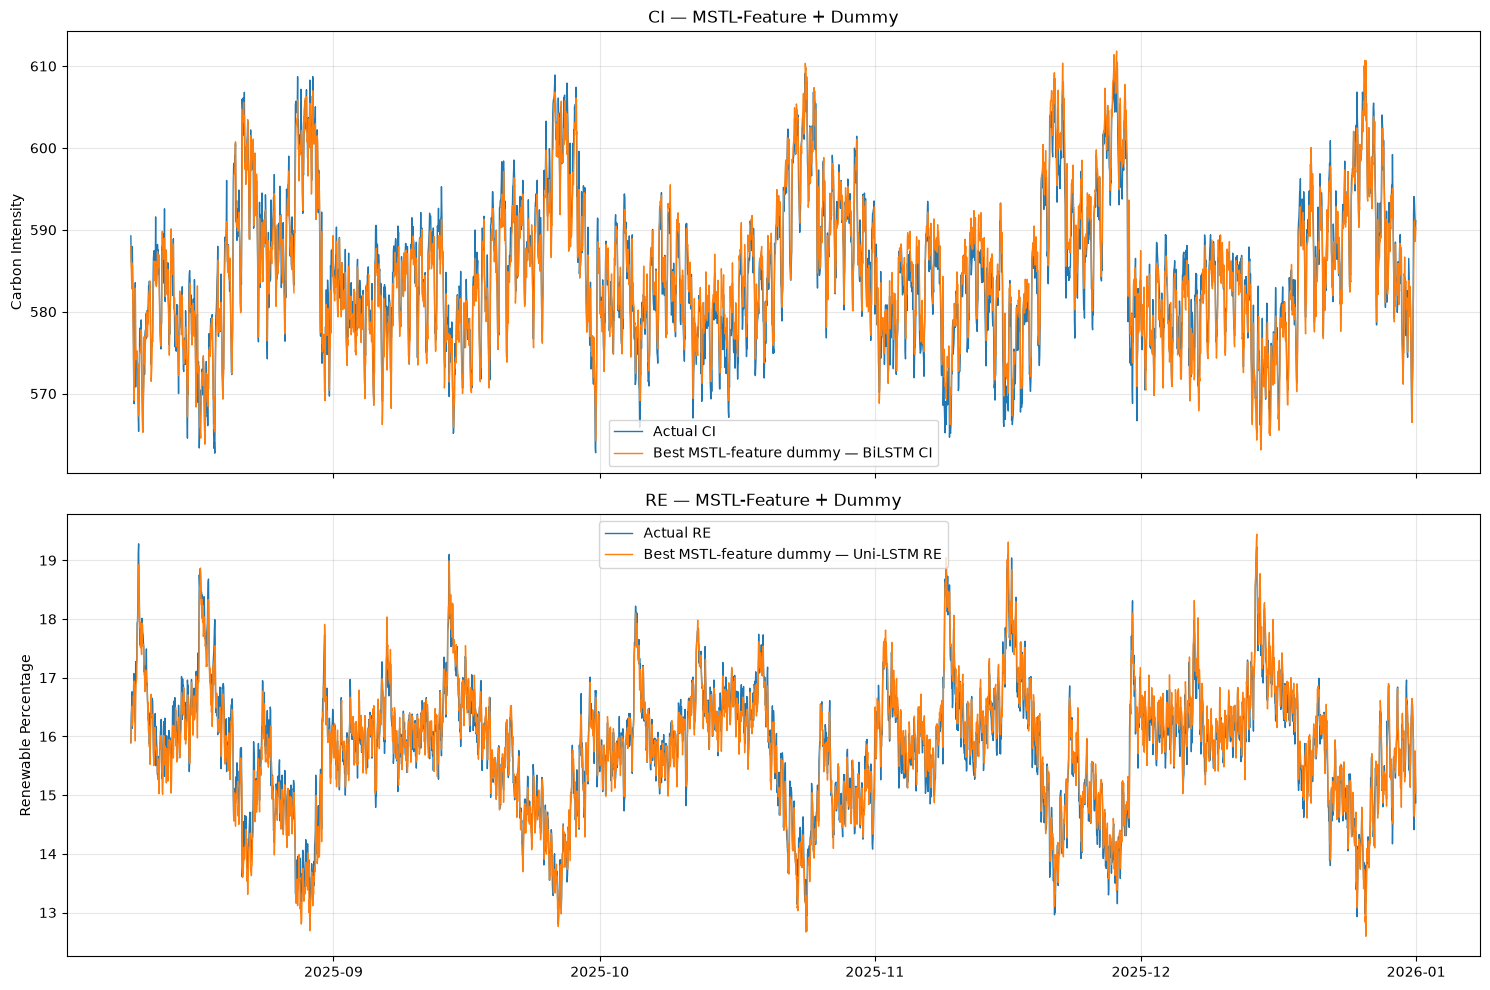

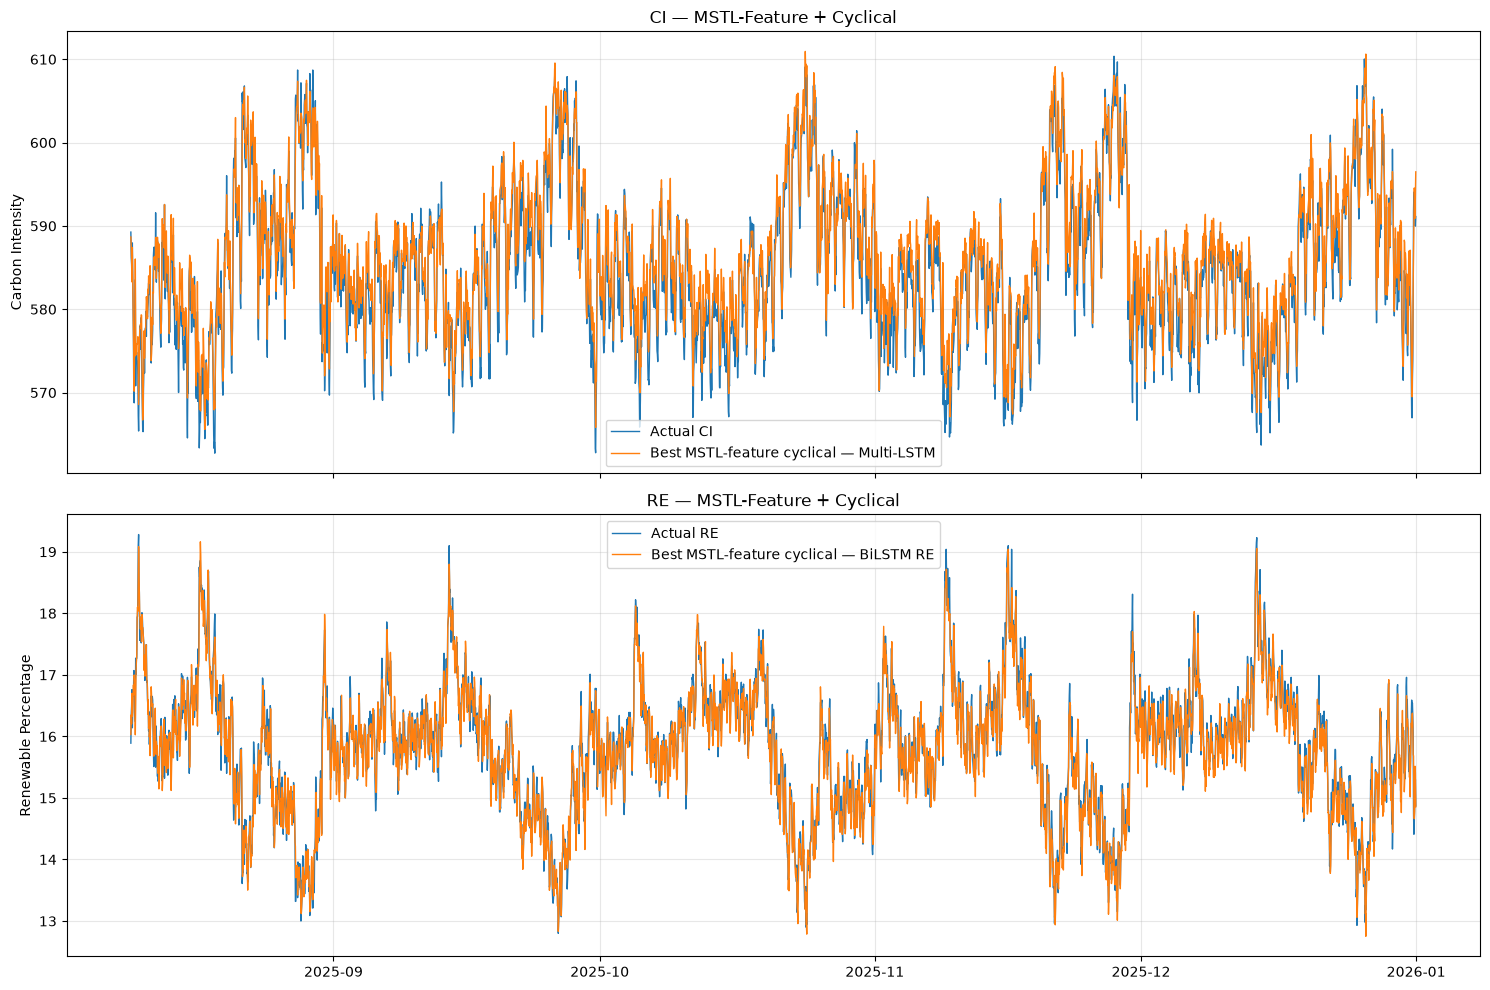

In [17]:
# Plot predictions for the best model in each temporal family.
# NOTE: test_index here must be offset by LOOK_BACK, since the sliding
# window consumes the first LOOK_BACK test rows as pure context.
plot_test_index = test_raw.index[LOOK_BACK:]
y_plot_actual = test_raw.iloc[LOOK_BACK:][[CI_COL, RE_COL]]

for temporal_mode in temporal_modes:
    subset = (
        results_df[results_df["Temporal"] == temporal_mode]
        .sort_values(["Target", "RMSE"])
    )

    best_ci = subset[subset["Target"] == "CI"].iloc[0]
    best_re = subset[subset["Target"] == "RE"].iloc[0]

    ci_key = (temporal_mode, best_ci["Model"])
    re_key = (temporal_mode, best_re["Model"])

    fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

    axes[0].plot(plot_test_index, y_plot_actual[CI_COL].values, label="Actual CI", linewidth=1)
    axes[0].plot(
        plot_test_index,
        all_predictions[ci_key]["CI"],
        label=f"Best MSTL-feature {temporal_mode} — {best_ci['Model']}",
        linewidth=1
    )
    axes[0].set_title(f"CI — MSTL-Feature + {temporal_mode.capitalize()}")
    axes[0].set_ylabel("Carbon Intensity")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(plot_test_index, y_plot_actual[RE_COL].values, label="Actual RE", linewidth=1)
    axes[1].plot(
        plot_test_index,
        all_predictions[re_key]["RE"],
        label=f"Best MSTL-feature {temporal_mode} — {best_re['Model']}",
        linewidth=1
    )
    axes[1].set_title(f"RE — MSTL-Feature + {temporal_mode.capitalize()}")
    axes[1].set_ylabel("Renewable Percentage")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

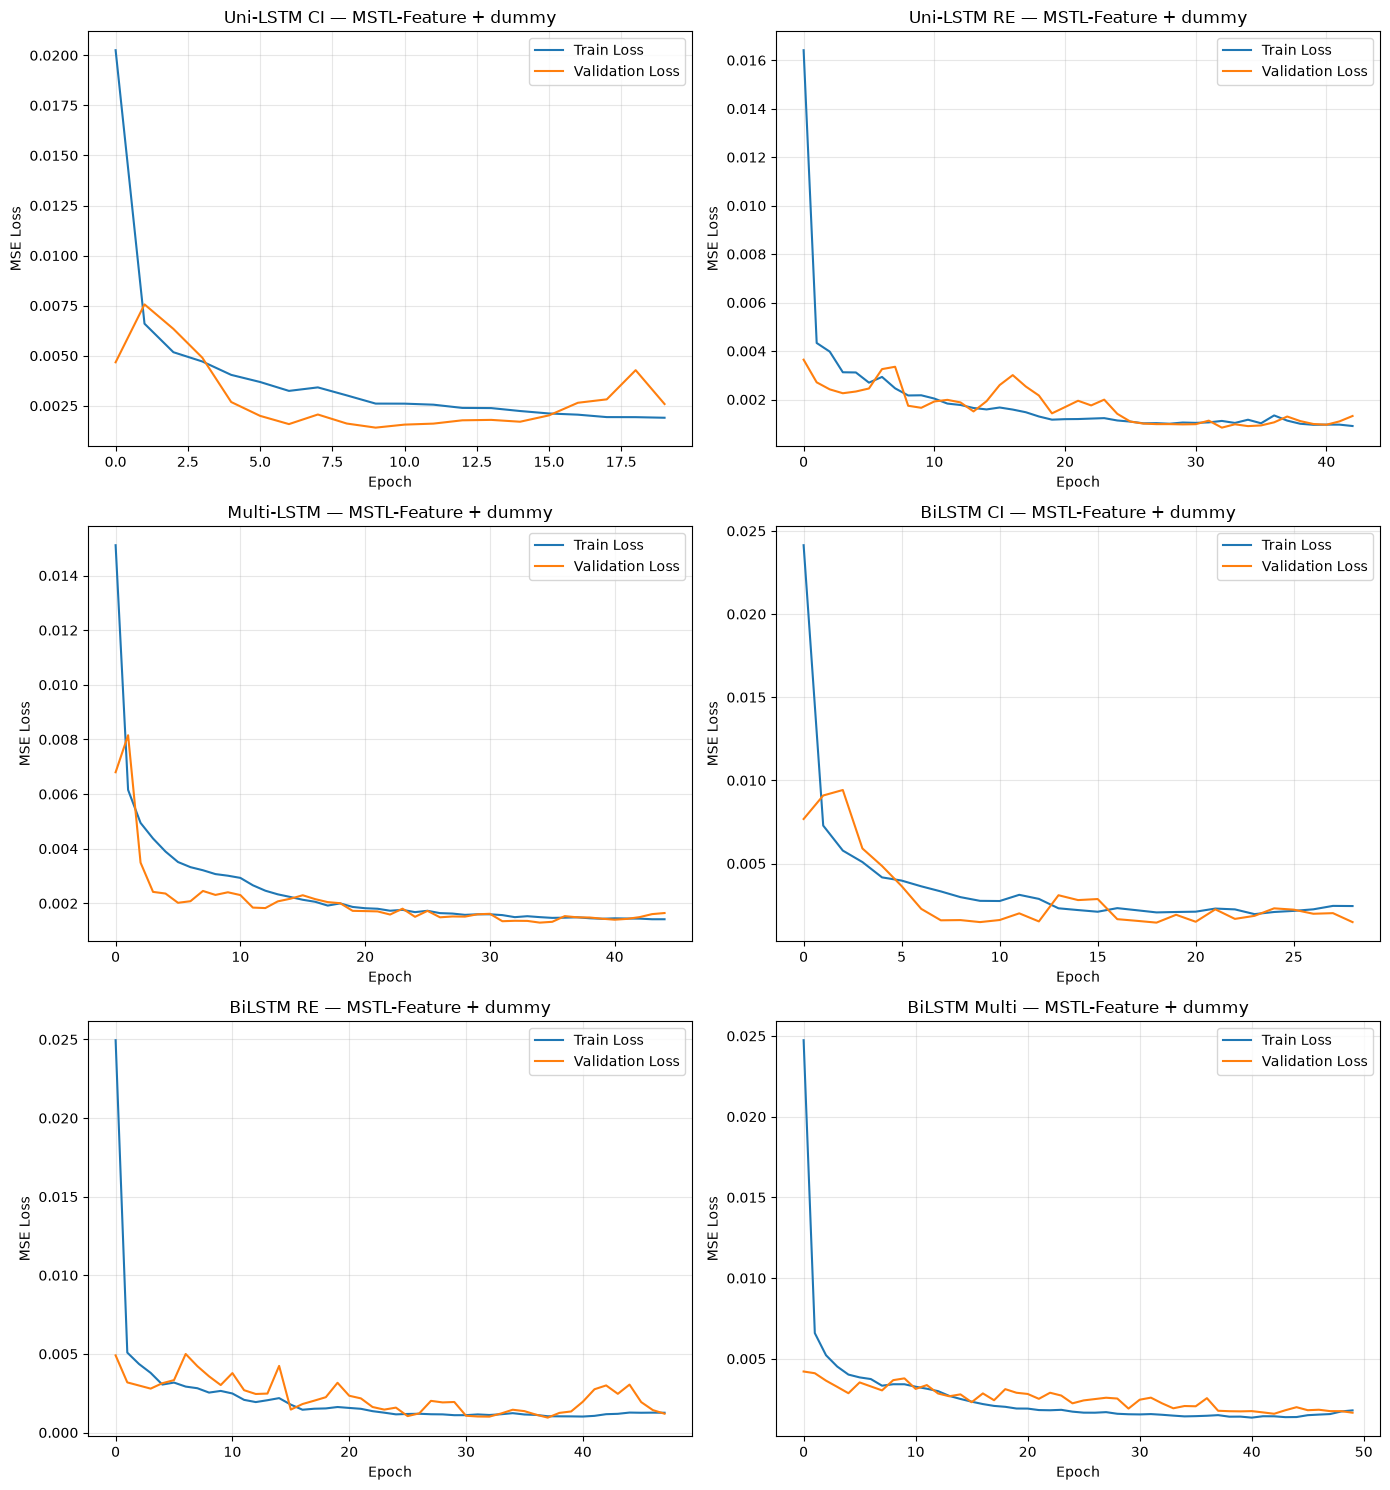

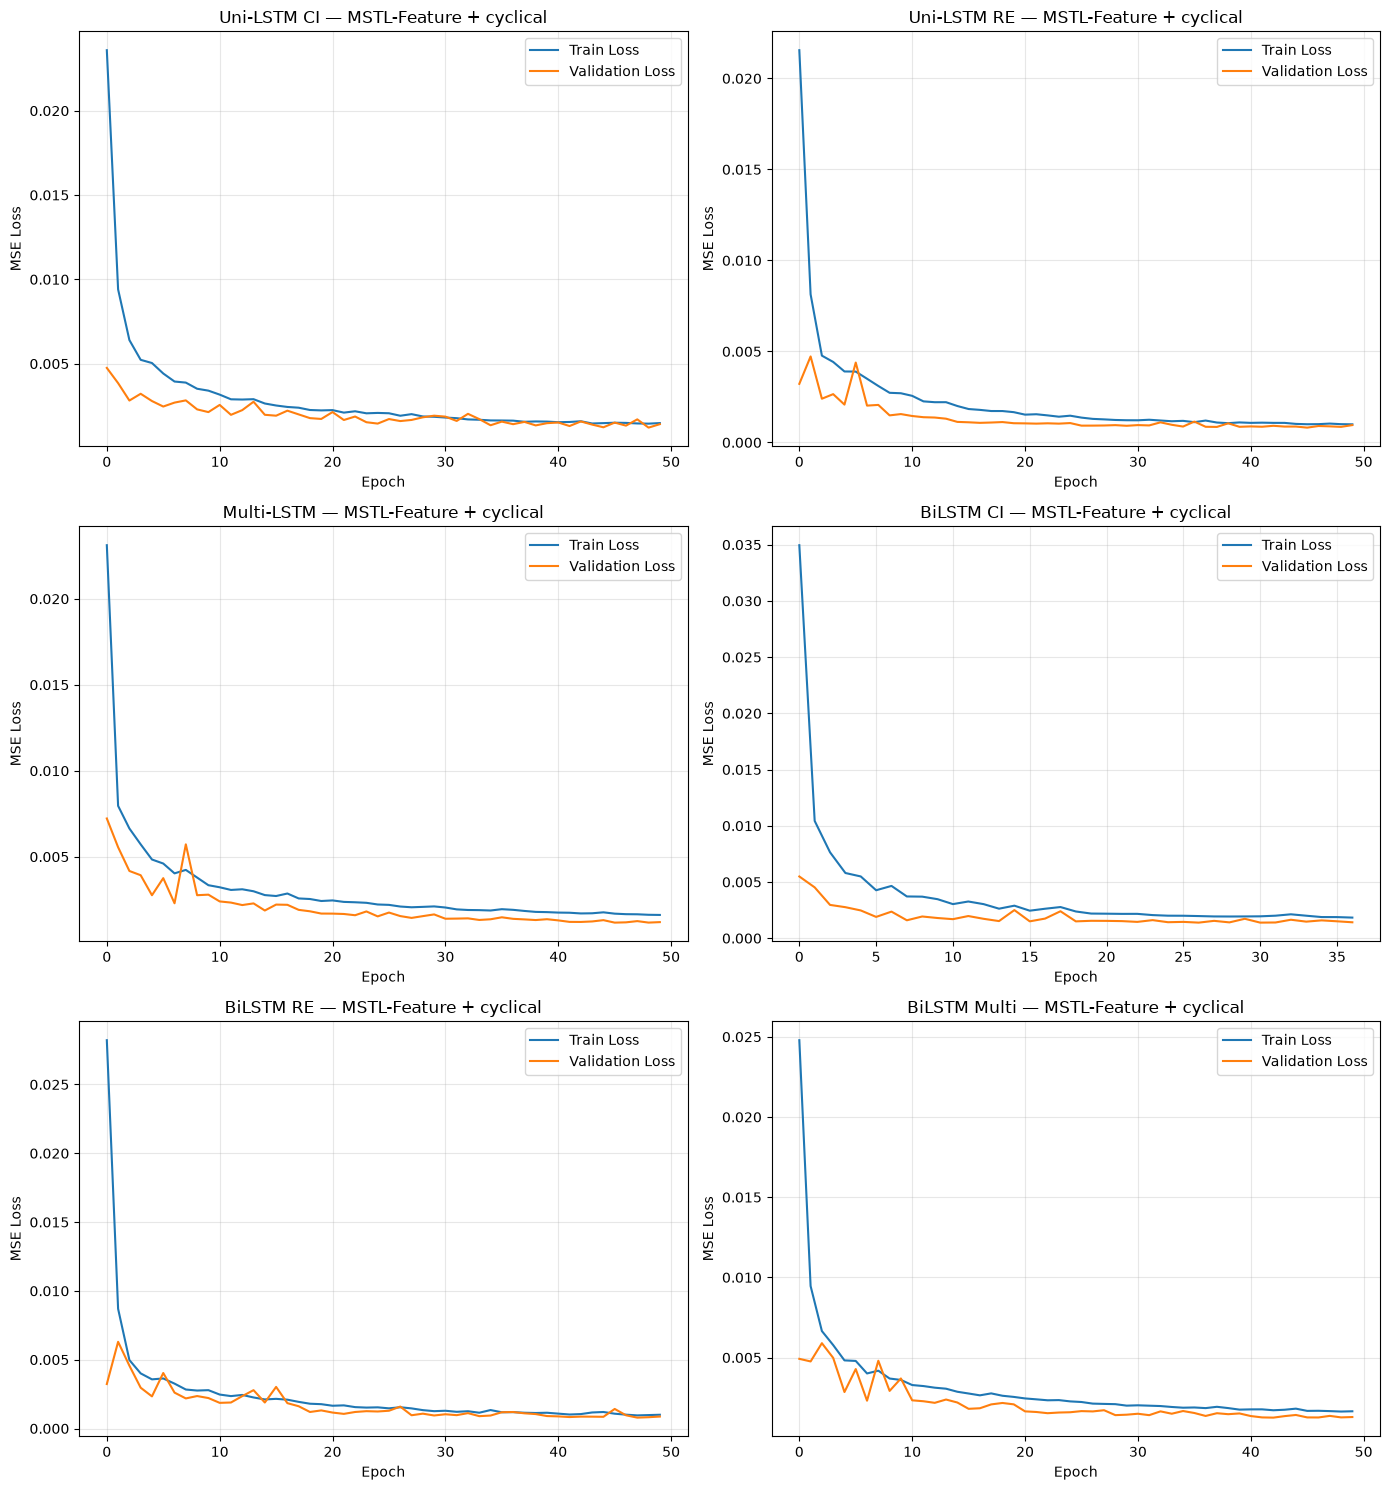

In [18]:
for temporal_mode in temporal_modes:
    histories = {
        model_name: all_histories[(temporal_mode, model_name)]
        for model_name, _, _ in experiment_specs
    }

    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    axes = axes.flatten()

    for ax, (name, history) in zip(axes, histories.items()):
        ax.plot(history.history["loss"], label="Train Loss")
        ax.plot(history.history["val_loss"], label="Validation Loss")
        ax.set_title(f"{name} — MSTL-Feature + {temporal_mode}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("MSE Loss")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [19]:
results_dir = project_root / "results" / "deep_learning"
results_dir.mkdir(parents=True, exist_ok=True)

results_path = results_dir / "06_dani_dl_mstl_feature_metrics.csv"
results_df.to_csv(results_path, index=False)

pivot_path = results_dir / "06_dani_dl_mstl_feature_dummy_vs_cyclical_rmse.csv"
pivot_rmse.to_csv(pivot_path, index=False)

print("Results saved to:")
print(results_path)
print(pivot_path)

Results saved to:
/Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/results/deep_learning/06_dani_dl_mstl_feature_metrics.csv
/Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/results/deep_learning/06_dani_dl_mstl_feature_dummy_vs_cyclical_rmse.csv


In [20]:
models_dir = project_root / "models" / "deep_learning"
models_dir.mkdir(parents=True, exist_ok=True)

for (temporal_mode, model_name), bundle in all_models.items():
    safe_model_name = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("-", "")
    )

    model_path = (
        models_dir
        / f"06_mstl_feature_{temporal_mode}_{safe_model_name}.keras"
    )

    bundle["model"].save(model_path)

print("All 12 MSTL-as-feature models saved.")

All 12 MSTL-as-feature models saved.
